# LangGraph 综合测试 Notebook
---
目标：验证 LangGraph `StateGraph` 基础流转，建立 `GlobalState` 定义与各层节点骨架。

**不包含**：完整 LLM 推理、Primitive 调用、RoboDK 连接。  
**约定**：所有生产逻辑在 `SkiLib/` 中实现，此 Notebook 仅用于框架验证。

In [1]:
# ── 依赖安装 ──────────────────────────────────────────────────────────────────
%pip install -q python-dotenv
%pip install -qU langchain-core langchain-ollama
%pip install -qU langgraph
%pip install -qU langchain-anthropic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.3 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
Note: you may need to restart the kernel to use updated packages.


In [12]:

# ── 导入与环境初始化 ───────────────────────────────────────────────────────────
import os,sys
# Jupyter notebooks don't define __file__, so locate the project root by
# searching upward for CLAUDE.md (the project marker file).
def _find_project_root(marker: str = "CLAUDE.md") -> str:
    path = os.path.abspath("")
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        path = os.path.dirname(path)
    raise RuntimeError(f"Project root not found (searched for '{marker}')")

_root = _find_project_root()
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Project root:", _root)
import getpass
import logging
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END

# 从项目根目录 .env 加载 API Key 与追踪配置
load_dotenv()

# LangSmith 追踪（可选 — 在 .env 中设置 LANGSMITH_TRACING=true 启用）
if os.getenv("LANGSMITH_TRACING", "false").lower() == "true":
    if not os.getenv("LANGSMITH_API_KEY"):
        os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter LangSmith API Key: ")
    if not os.getenv("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = getpass.getpass("Enter LangSmith Project name: ")

logging.basicConfig(level=logging.ERROR, force=True)
print("Environment loaded. LangSmith tracing:", os.getenv("LANGSMITH_TRACING", "false"))

Project root: c:\Users\fengy\RoboSkiAgent
Environment loaded. LangSmith tracing: true


In [13]:
LLM_TYPE = "claude"  # 可选 "claude" 或 "ollama"（本地）
# ── LLM 配置 ──────────────────────────────────────────────────────────────────
# 使用本地 Ollama 时修改 OLLAMA_MODEL_ID 切换模型
OLLAMA_MODEL_ID = os.getenv("OLLAMA_MODEL_ID", "qwen3:latest")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

if LLM_TYPE == "claude":
    llm = ChatAnthropic(
        model="claude-sonnet-4-6"
    )
else:
    llm = ChatOllama(
        model=OLLAMA_MODEL_ID,
        base_url=OLLAMA_BASE_URL,
        temperature=0,
    )

# 快速连通性检查
try:
    _ping = llm.invoke("Reply with one word: ready")
    print("LLM reachable:", _ping.content.strip()[:80])
except Exception as e:
    print(f"[WARN] LLM not reachable — nodes using llm will fail. ({e})")

LLM reachable: ready


## GlobalState
与 `CLAUDE.md` 中 `GlobalState` 规范保持一致。  
`robot_state` 此处用 `dict` 代替，生产版本从 `SkiLib.base` 导入 `RobotState`。

In [4]:
# ── GlobalState 定义 ──────────────────────────────────────────────────────────
from typing import TypedDict, Annotated, Optional, Literal
import operator


class GlobalState(TypedDict):
    # Layer-1：规划层输出
    todo_list: list[dict]           # [{task_id, type, skill/description, params}, ...]

    # Layer-2：执行上下文
    current_task: dict              # 执行槽：{} = 空闲，{...} = 执行中或失败保留

    # 机器人运行时快照（此处用 dict 代替，生产类型：SkiLib.base.RobotState）
    robot_state: dict

    # 控制标志
    halt_flag: bool                 # True = 所有 R-skill 执行被锁定
    halt_reason: Optional[str]      # "TASK_FAILURE" | "MANUAL_TASK" | None

    # Executor 写入；含 needs_hilp 字段供 Context Flush 决策
    last_result: Optional[dict]

    # 内部路由字段：human_intervention 写入，after_human_intervention 读取
    _hi_action: Optional[str]

    # 审计日志，由 Context Flush 写入；Annotated list 避免键覆盖
    execution_log: Annotated[list[str], operator.add]

    # LangGraph 消息总线
    messages: Annotated[list[BaseMessage], operator.add]


print("GlobalState keys:", list(GlobalState.__annotations__.keys()))

GlobalState keys: ['todo_list', 'current_task', 'robot_state', 'halt_flag', 'halt_reason', 'last_result', '_hi_action', 'execution_log', 'messages']


## Supervisor Task-Skills
Supervisor 在 ReAct 循环中调用这些工具收集领域知识，直到**知识饱和**（LLM 不再调用工具）。

| 工具 | 作用 |
|------|------|
| `query_assembly_spec` | 按零件 ID 查询装配规范（目标位、所需工具等） |
| `list_available_targets` | 列出工作空间内所有符号目标位 |
| `list_available_tools` | 列出机器人可用末端执行器 |
| `request_human_intervention` | 无法消除歧义时触发 HITL，系统挂起 |

**约束**：所有工具只返回符号 ID（`Part_A`、`Slot_1`），不含坐标。

In [14]:
# ── Supervisor Task-Skills ────────────────────────────────────────────────────
# Supervisor 通过这些工具收集领域知识，所有返回值只含符号 ID，不含坐标。
# 生产版本：由真实 YAML 规范文件 + RoboDK 工作空间查询提供支撑。
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, ToolMessage


@tool
def query_assembly_spec(part_id: str) -> str:
    """Query the assembly specification for a given part ID (e.g. Part_A)."""
    specs = {
        "Part_A": (
            "Part_A: M10 bolt. "
            "Pick target: Pick_Zone_A. "
            "Place target: Slot_1 on Tray_1. "
            "Required tool: Tool_Gripper. "
            "Pre-condition: gripper must be empty."
        ),
        "Part_B": (
            "Part_B: M10 washer. "
            "Pick target: Pick_Zone_B. "
            "Place target: Slot_2 on Tray_1. "
            "Required tool: Tool_Suction."
        ),
    }
    return specs.get(
        part_id,
        f"No spec found for '{part_id}'. Verify part ID or call request_human_intervention.",
    )


@tool
def list_available_targets() -> str:
    """List all available symbolic target positions in the workspace."""
    return (
        "Symbolic targets: Home, Pick_Zone_A, Pick_Zone_B, "
        "Slot_1 (on Tray_1), Slot_2 (on Tray_1)"
    )


@tool
def list_available_tools() -> str:
    """List all available robot end-effectors."""
    return "Available tools: Tool_Gripper (parallel jaw), Tool_Suction (vacuum cup)"


@tool
def request_human_intervention(reason: str) -> str:
    """
    Request human intervention when the instruction is ambiguous
    or beyond the robot's capability boundary. This halts the system.
    """
    return f"[HITL] Human intervention requested — reason: {reason}"


SUPERVISOR_TOOLS = [
    query_assembly_spec,
    list_available_targets,
    list_available_tools,
    request_human_intervention,
]
SUPERVISOR_TOOL_MAP = {t.name: t for t in SUPERVISOR_TOOLS}

print("Supervisor tools registered:", [t.name for t in SUPERVISOR_TOOLS])

Supervisor tools registered: ['query_assembly_spec', 'list_available_targets', 'list_available_tools', 'request_human_intervention']


## Node Implementations

各节点实现状态：

| 节点 | 层 | 状态 | 说明 |
|------|----|------|------|
| `supervisor` | Layer-1 | **已实现** | ReAct loop，调用 task-skills 迭代至知识饱和 |
| `planner` | Layer-1 | STUB | 生成硬编码 `todo_list`，支持 `type="auto"` 和 `type="manual"` |
| `dispatcher` | Layer-2 | **已实现** | 纯代码；auto 任务 → Executor；manual 任务 → human_intervention |
| `executor` | Layer-2 | STUB | 模拟执行，写入含 `needs_hilp` 的 `last_result` |
| `context_flush` | Layer-2 | **已实现** | 成功清槽；失败且 `needs_hilp=True` → halt + `halt_reason="TASK_FAILURE"` |
| `human_intervention` | Layer-2 | **已实现** | `interrupt()` 暂停；支持 `retry` / `complete` / `abort` 三动作 |

### todo_list 任务格式

```python
# 自动任务（由 Executor 执行）
{"task_id": "t1", "type": "auto",   "skill": "PickAndPlace", "params": {...}}

# 人工任务（直接触发 human_intervention 节点）
{"task_id": "t2", "type": "manual", "description": "手动拧紧 M10 螺栓至 25 N·m"}
```

Planner 可在同一 `todo_list` 中混排 auto/manual 任务，Dispatcher 按 `type` 字段自动路由，无需 LLM 介入。

In [ ]:
# ── 节点：Supervisor（新版，create_react_agent）────────────────────────────────
# 原版手动 ReAct 循环见下方 Cell（已注释保留）。
# NOTE: response_format 不用于 Claude — Claude 不支持 assistant prefill。
#       结构化提取在 ReAct 循环结束后单独追加 HumanMessage 再调 with_structured_output。
import json
from langgraph.prebuilt import create_react_agent
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage as _HumanMessage
from SkiLib.metatools.informative import get_tools as get_info_tools
from SkiLib.registry import SkillRegistry


# ── SupervisorOutput Schema ───────────────────────────────────────────────────
class SupervisorOutput(BaseModel):
    """Fact sheet produced after knowledge saturation. Symbol-only, no coordinates."""
    task_intent_original: str = Field(description="Verbatim user instruction")
    task_intent: str = Field(
        description="Rewritten instruction using exact RoboDK symbol names"
    )
    scene: dict = Field(
        description="Keys: targets (list[str]), objects (list[str]), tools (list[str])"
    )
    extra_info: str = Field(
        default="",
        description="Unresolvable ambiguities or free-text observations"
    )


def _get_available_skills() -> dict:
    registry = SkillRegistry.instance()
    if not registry:
        return {}
    return {
        name: registry.get_skill(name).execute.__doc__ or ""
        for name in registry.list_skills()
    }


def _build_supervisor_prompt() -> str:
    skills_text = "\n".join(
        f"  - {name}: {doc.strip()}"
        for name, doc in _get_available_skills().items()
    ) or "  (none registered)"
    return f"""\
You are the Supervisor agent in an industrial robot assembly system.
Your ONLY job: gather scene facts and produce a structured SupervisorOutput summary.
Do NOT plan tasks, choose skills, or compute coordinates.

Rules:
- Call tools to query the RoboDK scene until you have enough information.
- Rewrite the instruction in `task_intent` using exact RoboDK symbol names.
- All `scene` fields must use exact names returned by query tools — no invented names.
- Never include coordinates, joint angles, or numeric poses.
- Record unresolvable ambiguities in `extra_info` instead of guessing.

Available skills (reference only — do not invent new ones):
{skills_text}
"""


_supervisor_agent = None

def _get_supervisor_agent():
    global _supervisor_agent
    if _supervisor_agent is None:
        _supervisor_agent = create_react_agent(
            llm,
            tools=get_info_tools(),
            prompt=_build_supervisor_prompt(),
        )
        print("[supervisor] Agent built. Skills:", list(_get_available_skills().keys()))
    return _supervisor_agent


def supervisor(state: GlobalState) -> dict:
    # Step 1: ReAct loop — calls informative tools, produces text summary
    result = _get_supervisor_agent().invoke({"messages": state["messages"]})

    # Step 2: Structured extraction — append user turn (Claude forbids assistant prefill)
    extraction_messages = list(result["messages"]) + [
        _HumanMessage(content=(
            "Based on your analysis above, fill in the SupervisorOutput schema. "
            "Use ONLY the exact names you retrieved from the tools — do not invent any."
        ))
    ]
    structured_llm = llm.with_structured_output(SupervisorOutput, method="json_schema")
    summary: SupervisorOutput = structured_llm.invoke(extraction_messages)

    output = summary.model_dump()
    output["available_skills"] = _get_available_skills()

    return {"messages": [AIMessage(content=json.dumps(output, ensure_ascii=False))]}


print("Supervisor cell loaded.")

In [ ]:
# ── Supervisor 单元测试 ───────────────────────────────────────────────────────
# 前提：RoboDK 已启动

from SkiLib.robotcontext import RobotContext
from SkiLib.registry import SkillRegistry

# 1. 拉起 RoboDK API
context = RobotContext()
RDK    = context.RDK
robot  = context.robot
skill_registry = SkillRegistry.instance()
print("[init] RobotContext OK, skills:", skill_registry.list_skills())

# 2. 重置 supervisor 单例（使其用已初始化的 SkillRegistry 重建）
_supervisor_agent = None

# 3. 构造最小初始状态
_test_state = {
    "messages":      [HumanMessage(content="把 Part_A_1 放到 Place Part A")],
    "todo_list":     [], "current_task": {}, "robot_state": {},
    "halt_flag":     False, "halt_reason": None,
    "last_result":   None, "_hi_action":  None, "execution_log": [],
}

# 4. 运行
print("\n[test] Running supervisor...")
_updates = supervisor(_test_state)

# 5. 解析输出
_out = json.loads(_updates["messages"][-1].content)
print("\n[SupervisorOutput]")
print(f"  task_intent_original : {_out['task_intent_original']}")
print(f"  task_intent          : {_out['task_intent']}")
print(f"  scene.targets        : {_out['scene'].get('targets')}")
print(f"  scene.objects        : {_out['scene'].get('objects')}")
print(f"  available_skills     : {list(_out.get('available_skills', {}).keys())}")
print(f"  extra_info           : {_out.get('extra_info', '')!r}")

In [16]:
# ── 节点：Supervisor（旧版，手动 ReAct 循环）────────────────────────────────────
# 新版见上方 Cell（create_react_agent）。此版本已注释，保留供对比参考。

# _SUPERVISOR_SYSTEM_PROMPT = """\
# You are the Supervisor of an industrial robot assembly system.
# ...（原 prompt 略，见 git history）
# """

# def supervisor(state: GlobalState) -> dict:
#     """ReAct loop: LLM calls task-skills iteratively until knowledge saturation."""
#     llm_with_tools = llm.bind_tools(SUPERVISOR_TOOLS)
#     loop_msgs = [SystemMessage(content=_SUPERVISOR_SYSTEM_PROMPT)] + list(state["messages"])
#     initial_len = len(loop_msgs)
#     MAX_ITER = 6
#     for iteration in range(MAX_ITER):
#         response = llm_with_tools.invoke(loop_msgs)
#         loop_msgs.append(response)
#         if not response.tool_calls:
#             print("[supervisor] Knowledge saturation reached.")
#             break
#         for tc in response.tool_calls:
#             fn = SUPERVISOR_TOOL_MAP.get(tc["name"])
#             result = fn.invoke(tc["args"]) if fn else f"Unknown tool: {tc['name']}"
#             loop_msgs.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
#     new_msgs = loop_msgs[initial_len:]
#     return {"messages": new_msgs}


# ── 节点：Planner ─────────────────────────────────────────────────────────────
# 职责：通过强制结构化输出生成 todo_list JSON 任务队列。
# 支持 type="auto"（自动执行）和 type="manual"（触发 human_intervention）混排。
# TODO：替换为真实 LLM 结构化输出 + Pydantic schema + retry
def planner(state: GlobalState) -> dict:
    print("[planner] Generating task plan...")
    todo = [
        {"task_id": "t1", "type": "auto",   "skill": "MoveJ",       "params": {"target": "Home"}},
        {"task_id": "t2", "type": "auto",   "skill": "PickAndPlace", "params": {"pick": "Pick_Zone_A", "place": "Slot_1"}},
        {"task_id": "t3", "type": "manual", "description": "手动拧紧 M10 螺栓至 25 N·m"},
        {"task_id": "t4", "type": "auto",   "skill": "MoveJ",       "params": {"target": "Home"}},
    ]
    return {
        "todo_list": todo,
        "messages":  [AIMessage(content=f"[Planner] {len(todo)} tasks queued ({sum(1 for t in todo if t.get('type')=='manual')} manual)")],
    }


# ── 节点：Dispatcher（纯代码，无 LLM）────────────────────────────────────────
# 职责：填充执行槽 — 仅当 current_task == {} 时 pop todo_list[0]。
# manual 任务：同时设 halt_flag=True + halt_reason="MANUAL_TASK"，
#             由 after_dispatcher 条件边路由到 human_intervention。
# 约束：100% 确定性；禁止调用任何 LLM。
def dispatcher(state: GlobalState) -> dict:
    if state.get("current_task"):
        print(f"[dispatcher] 槽已占用：{state['current_task'].get('task_id')} — 跳过。")
        return {}
    todo = list(state.get("todo_list", []))
    if not todo:
        print("[dispatcher] todo_list 为空，无任务可调度。")
        return {}
    task = todo.pop(0)
    print(f"[dispatcher] Dispatching: {task.get('task_id')} (type={task.get('type','auto')})")
    result: dict = {"current_task": task, "todo_list": todo}
    if task.get("type") == "manual":
        result["halt_flag"]   = True
        result["halt_reason"] = "MANUAL_TASK"
        print(f"[dispatcher] → Manual task, flagging HITL.")
    return result


def after_dispatcher(state: GlobalState) -> str:
    """Dispatcher 之后的条件路由：manual → human_intervention；auto → executor；空 → done。"""
    task = state.get("current_task", {})
    if not task:
        return "done"
    if task.get("type") == "manual":
        return "manual"
    return "auto"


# ── 节点：Executor ────────────────────────────────────────────────────────────
# 职责：执行 current_task 对应的 Skill，将结果写入 last_result。
# TODO：替换为动态 Skill 加载器 + SkiLib.base.SkillResult
def executor(state: GlobalState) -> dict:
    task = state.get("current_task", {})
    if not task:
        return {
            "execution_log": ["[executor] 无任务，跳过。"],
            "last_result": {"success": True, "needs_hilp": False},
        }
    if state.get("halt_flag"):
        return {
            "execution_log": [f"[executor] 已挂起 — 跳过 {task.get('task_id')}"],
            "last_result": {"success": False, "error_type": "ROBOT_INACTIVE", "needs_hilp": True},
        }
    print(f"[executor] Running: {task.get('skill')}({task.get('params')})")
    return {
        "execution_log": [f"[executor] {task['task_id']} {task.get('skill')} -> SUCCESS (stub)"],
        "last_result": {"success": True, "needs_hilp": False},
    }


# ── 节点：Context Flush（纯代码）──────────────────────────────────────────────
def context_flush(state: GlobalState) -> dict:
    task_id = state.get("current_task", {}).get("task_id", "?")
    last_result = state.get("last_result") or {}

    if last_result.get("success"):
        entry = f"[context_flush] {task_id} committed."
        print(entry)
        return {
            "current_task": {},
            "last_result":  None,
            "halt_reason":  None,
            "execution_log": [entry],
        }
    else:
        error_type = last_result.get("error_type", "UNKNOWN")
        entry = f"[context_flush] {task_id} FAILED ({error_type}) — halting, task retained."
        print(entry)
        return {
            "halt_flag":     True,
            "halt_reason":   "TASK_FAILURE",
            "execution_log": [entry],
        }


# ── 节点：HumanIntervention ───────────────────────────────────────────────────
from langgraph.types import interrupt

def human_intervention(state: GlobalState) -> dict:
    halt_reason  = state.get("halt_reason", "TASK_FAILURE")
    current_task = state.get("current_task", {})

    operator_response = interrupt({
        "halt_reason":  halt_reason,
        "current_task": current_task,
        "todo_list":    state.get("todo_list", []),
        "execution_log": state.get("execution_log", []),
    })

    action = operator_response.get("action", "abort")

    if action == "retry" and halt_reason == "MANUAL_TASK":
        print("[human_intervention] 警告：manual 任务不支持 retry，已降级为 abort。")
        action = "abort"

    if action == "retry":
        return {
            "halt_flag":  False, "halt_reason": None, "_hi_action": "retry",
            "execution_log": [f"[human_intervention] {current_task.get('task_id')} → retry"],
        }
    elif action == "complete":
        return {
            "halt_flag": False, "halt_reason": None, "current_task": {}, "last_result": None,
            "_hi_action": "complete",
            "execution_log": [f"[human_intervention] {current_task.get('task_id')} → manual complete"],
        }
    else:
        return {
            "halt_flag": False, "halt_reason": None, "current_task": {}, "todo_list": [],
            "last_result": None, "_hi_action": "abort",
            "execution_log": [f"[human_intervention] {current_task.get('task_id')} → abort"],
        }


def after_human_intervention(state: GlobalState) -> str:
    return state.get("_hi_action", "abort")


print("All nodes defined.")

All nodes defined.


## Graph Construction
流转顺序：`START → supervisor → planner → [dispatcher → executor → context_flush] × N → END`

`should_continue` 路由逻辑（优先级从高到低）：

| 条件 | 路由 | 说明 |
|------|------|------|
| `halt_flag=True` | `halt → END` | 执行失败或人工介入请求；`current_task` 保留，resume 后重试 |
| `todo_list` 非空 | `continue → dispatcher` | 槽已清空，取下一个任务 |
| 其他 | `done → END` | 队列清空，正常结束 |

**`current_task` 作为执行槽的状态语义：**
- `{}` → 槽空闲，Dispatcher 负责填充
- `{...}` → 任务在执行中（或失败保留），Dispatcher 跳过不覆盖

In [17]:
# ── 图构建 ────────────────────────────────────────────────────────────────────
# 拓扑：
#   START → supervisor → planner → dispatcher
#                                      │
#                         (auto) ──────┤──────── executor → context_flush
#                         (manual) ────┘              │
#                                                 (halt) ──→ human_intervention
#                                                               │
#                                          retry ──────────────┤→ executor
#                                          complete ───────────┤→ dispatcher
#                                          abort ──────────────┘→ END

from langgraph.checkpoint.memory import MemorySaver

def should_continue(state: GlobalState) -> str:
    """context_flush 之后的路由条件。优先级：halt > continue > done。"""
    if state.get("halt_flag"):
        return "halt"
    if state.get("todo_list") or state.get("current_task"):
        return "continue"
    return "done"


builder = StateGraph(GlobalState)

# 注册节点
builder.add_node("supervisor",         supervisor)
builder.add_node("planner",            planner)
builder.add_node("dispatcher",         dispatcher)
builder.add_node("executor",           executor)
builder.add_node("context_flush",      context_flush)
builder.add_node("human_intervention", human_intervention)

# Layer-1：线性流转
builder.add_edge(START,        "supervisor")
builder.add_edge("supervisor", "planner")
builder.add_edge("planner",    "dispatcher")

# Layer-2：Dispatcher 条件路由（auto / manual / 空队列）
builder.add_conditional_edges(
    "dispatcher",
    after_dispatcher,
    {
        "auto":   "executor",            # 自动任务 → Executor
        "manual": "human_intervention",  # 人工任务 → 直接 HITL
        "done":   END,                   # 空队列且槽空 → 结束
    },
)

# Layer-2：执行循环
builder.add_edge("executor", "context_flush")
builder.add_conditional_edges(
    "context_flush",
    should_continue,
    {
        "continue": "dispatcher",        # 槽已清空，取下一个任务
        "done":     END,                 # 队列清空，正常结束
        "halt":     "human_intervention",# 执行失败，等待人工
    },
)

# HumanIntervention 出口：retry / complete / abort
builder.add_conditional_edges(
    "human_intervention",
    after_human_intervention,
    {
        "retry":    "executor",          # 重试同一任务
        "complete": "dispatcher",        # 手动任务完成，继续队列
        "abort":    END,                 # 放弃
    },
)

# 使用 MemorySaver 支持 interrupt/resume
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled.")
print(graph.get_graph().draw_mermaid())

Graph compiled.
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	planner(planner)
	dispatcher(dispatcher)
	executor(executor)
	context_flush(context_flush)
	human_intervention(human_intervention)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	context_flush -. &nbsp;done&nbsp; .-> __end__;
	context_flush -. &nbsp;continue&nbsp; .-> dispatcher;
	context_flush -. &nbsp;halt&nbsp; .-> human_intervention;
	dispatcher -. &nbsp;done&nbsp; .-> __end__;
	dispatcher -. &nbsp;auto&nbsp; .-> executor;
	dispatcher -. &nbsp;manual&nbsp; .-> human_intervention;
	executor --> context_flush;
	human_intervention -. &nbsp;abort&nbsp; .-> __end__;
	human_intervention -. &nbsp;complete&nbsp; .-> dispatcher;
	human_intervention -. &nbsp;retry&nbsp; .-> executor;
	planner --> dispatcher;
	supervisor --> planner;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



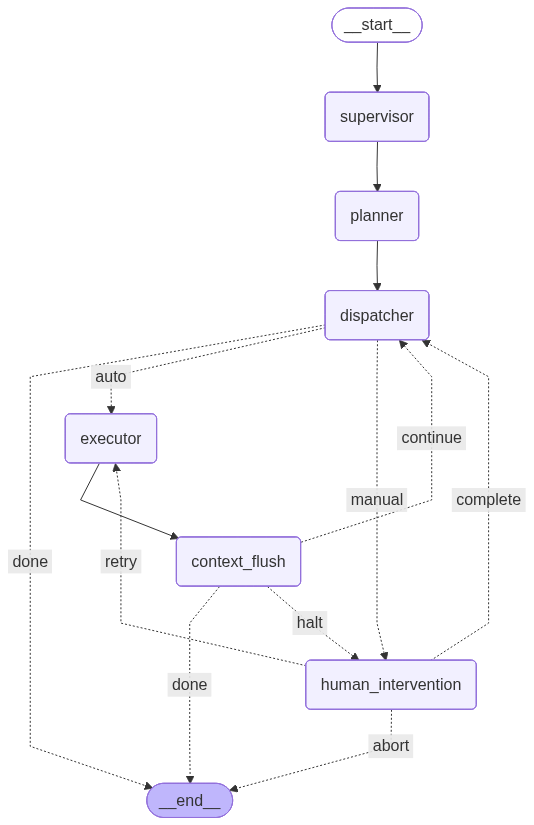

In [18]:
# 可选：可视化图结构（需要 graphviz）
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization skipped:", e)
    print(graph.get_graph().draw_mermaid())

## Test Run

In [20]:
# ── 工具函数：构建初始状态 ────────────────────────────────────────────────────
def make_initial_state(instruction: str) -> GlobalState:
    return {
        "messages":      [HumanMessage(content=instruction)],
        "todo_list":     [],
        "current_task":  {},
        "robot_state":   {"joints": None, "pose": None, "gripper_state": "UNKNOWN"},
        "halt_flag":     False,
        "halt_reason":   None,
        "last_result":   None,
        "_hi_action":    None,
        "execution_log": [],
    }

# ── 测试用例 1：正常指令（含 manual 任务，需 interrupt/resume）────────────────
# Planner stub 会输出 [t1 auto, t2 auto, t3 manual, t4 auto]
# t3 会触发 interrupt，需要操作员发送 complete 后继续执行 t4

from langgraph.types import Command

from SkiLib.robotcontext import RobotContext

config = {"configurable": {"thread_id": "test1"}}

print("=" * 60)
print("TEST 1: 含 manual 任务的完整流程")
print("=" * 60)


context = RobotContext()
RDK   = context.RDK
robot = context.robot
skill_registry = SkillRegistry.instance()

# 第一次 invoke — 执行到 t3 manual 时 interrupt
try:
    result = graph.invoke(make_initial_state("将 Part_A 装入 Tray_1"), config=config)
    print("（无 interrupt，直接完成）", result.get("execution_log"))
except Exception as e:
    # LangGraph interrupt 在 stream 模式下才能捕获，invoke 会抛出
    print(f"Interrupted: {e}")

# 检查当前状态
snapshot = graph.get_state(config)
print("\n── 当前状态快照 ─────────────────────────────────────")
print(f"  halt_reason : {snapshot.values.get('halt_reason')}")
print(f"  current_task: {snapshot.values.get('current_task')}")
print(f"  todo_list   : {[t['task_id'] for t in snapshot.values.get('todo_list', [])]}")
print(f"  next nodes  : {snapshot.next}")

2026-03-23 14:33:39,488 [INFO] SkiLib.registry — SkillRegistry: registered 'DummySkill'
2026-03-23 14:33:39,490 [INFO] SkiLib.registry — SkillRegistry: registered 'PickAndPlace'


TEST 1: 含 manual 任务的完整流程
[PrimitiveRegistry] Registered: Grasp
[PrimitiveRegistry] Registered: Release
[PrimitiveRegistry] Registered: MoveJ
[PrimitiveRegistry] Registered: MoveL
[DummySkill] __init__ called. Received primitives: ['Grasp', 'Release', 'MoveJ', 'MoveL']
[planner] Generating task plan...
[dispatcher] Dispatching: t1 (type=auto)
[executor] Running: MoveJ({'target': 'Home'})
[context_flush] t1 committed.
[dispatcher] Dispatching: t2 (type=auto)
[executor] Running: PickAndPlace({'pick': 'Pick_Zone_A', 'place': 'Slot_1'})
[context_flush] t2 committed.
[dispatcher] Dispatching: t3 (type=manual)
[dispatcher] → Manual task, flagging HITL.
（无 interrupt，直接完成） ['[executor] t1 MoveJ -> SUCCESS (stub)', '[context_flush] t1 committed.', '[executor] t2 PickAndPlace -> SUCCESS (stub)', '[context_flush] t2 committed.']

── 当前状态快照 ─────────────────────────────────────
  halt_reason : MANUAL_TASK
  current_task: {'task_id': 't3', 'type': 'manual', 'description': '手动拧紧 M10 螺栓至 25 N·m'}
  to

In [10]:
# ── 测试用例 1 续：操作员 resume（complete）─────────────────────────────────
print("=" * 60)
print("TEST 1 续：操作员确认 manual 任务完成 → complete")
print("=" * 60)

result2 = graph.invoke(
    Command(resume={"action": "complete"}),
    config=config,
)
print("\nExecution log:")
for entry in result2["execution_log"]:
    print(" ", entry)
print("halt_flag:", result2.get("halt_flag"))
print("todo_list:", result2.get("todo_list"))

TEST 1 续：操作员确认 manual 任务完成 → complete
[human_intervention] t3 → complete (manual done)
[dispatcher] Dispatching: t4 (type=auto)
[executor] Running: MoveJ({'target': 'Home'})
[context_flush] t4 committed.

Execution log:
  [executor] t1 MoveJ -> SUCCESS (stub)
  [context_flush] t1 committed.
  [executor] t2 PickAndPlace -> SUCCESS (stub)
  [context_flush] t2 committed.
  [human_intervention] t3 → manual complete
  [executor] t4 MoveJ -> SUCCESS (stub)
  [context_flush] t4 committed.
halt_flag: False
todo_list: []


In [11]:
# ── 测试用例 2：任务失败触发 HITL → retry ────────────────────────────────────
# 临时 patch executor 让第一个任务失败，验证 TASK_FAILURE → retry 路径

_original_executor = executor

def _failing_executor(state: GlobalState) -> dict:
    task = state.get("current_task", {})
    # 仅让 t1 失败一次（通过检查 execution_log 是否已有 retry 记录）
    logs = state.get("execution_log", [])
    already_retried = any("retry" in l for l in logs)
    if task.get("task_id") == "t1" and not already_retried:
        print(f"[executor] STUB FAIL: {task.get('task_id')}")
        return {
            "execution_log": [f"[executor] {task['task_id']} FAILED (stub)"],
            "last_result": {"success": False, "error_type": "IK_FAILURE", "needs_hilp": True},
        }
    return _original_executor(state)

# 注入失败版本（仅本 cell 范围内测试）
import SkiLib.graph as _g  # noqa — 仅用于临时替换
_g_nodes = graph.nodes  # 图已编译，节点函数直接在 closure 中，patch 需重建图

# 为避免重建图，这里直接展示期望的流转，通过 state 手动模拟：
config2 = {"configurable": {"thread_id": "test2"}}

# 手动构造：t1 已失败的状态（跳过 supervisor/planner，直接进入执行循环）
# context_flush 看到 success=False, needs_hilp=True → 设 halt
failed_state: GlobalState = {
    "messages":      [],
    "todo_list":     [{"task_id": "t2", "type": "auto", "skill": "MoveJ", "params": {"target": "Home"}}],
    "current_task":  {"task_id": "t1", "type": "auto", "skill": "MoveJ", "params": {"target": "Home"}},
    "robot_state":   {},
    "halt_flag":     False,
    "halt_reason":   None,
    "last_result":   {"success": False, "error_type": "IK_FAILURE", "needs_hilp": True},
    "_hi_action":    None,
    "execution_log": ["[executor] t1 FAILED (IK_FAILURE)"],
}

# 直接调用 context_flush 逻辑验证输出
flush_out = context_flush(failed_state)
print("context_flush output:", flush_out)
assert flush_out["halt_flag"] == True
assert flush_out["halt_reason"] == "TASK_FAILURE"
assert "current_task" not in flush_out  # current_task 应保持不变
print("✓ TASK_FAILURE path: halt_flag=True, halt_reason=TASK_FAILURE, current_task preserved")

ModuleNotFoundError: No module named 'SkiLib'

In [12]:
# ── 测试用例 3：歧义指令 — Supervisor 调用 request_human_intervention ─────────
config3 = {"configurable": {"thread_id": "test3"}}

print("=" * 60)
print("TEST 3: 歧义指令（Supervisor 应触发 HITL）")
print("=" * 60)

try:
    graph.invoke(make_initial_state("把那个零件放好"), config=config3)
except Exception as e:
    print(f"Interrupted: {e}")

snapshot3 = graph.get_state(config3)
print(f"\nhalt_reason : {snapshot3.values.get('halt_reason')}")
print(f"next nodes  : {snapshot3.next}")

TEST 3: 歧义指令（Supervisor 应触发 HITL）
[supervisor] iter=1, tool_calls=2
  ↳ list_available_targets({}) → Symbolic targets: Home, Pick_Zone_A, Pick_Zone_B, Slot_1 (on Tray_1), Slot_2 (on Tray_1)
  ↳ list_available_tools({}) → Available tools: Tool_Gripper (parallel jaw), Tool_Suction (vacuum cup)
[supervisor] iter=2, tool_calls=2
  ↳ query_assembly_spec({'part_id': 'Part_A'}) → Part_A: M10 bolt. Pick target: Pick_Zone_A. Place target: Slot_1 on Tray_1. Required tool: Tool_Grip
  ↳ query_assembly_spec({'part_id': 'Part_B'}) → Part_B: M10 washer. Pick target: Pick_Zone_B. Place target: Slot_2 on Tray_1. Required tool: Tool_Su
[supervisor] iter=3, tool_calls=1
  ↳ request_human_intervention({'reason': '指令"把那个零件放好"存在关键歧义：系统中存在两个零件（Part_A: M10螺栓 和 Part_B: M10垫片），无法确定"那个零件"具体指哪一个。请明确指定目标零件ID（Part_A 或 Part_B），以便系统继续执行。'}) → [HITL] Human intervention requested — reason: 指令"把那个零件放好"存在关键歧义：系统中存在两个零件（Part_A: M10螺栓 和 Part_B: M1
[supervisor] iter=4, tool_calls=0
[supervisor] Knowledge saturation reached